# Phase 3: Model Selection & Training
## Project: Fuel Efficiency Prediction (MPG)

**Objective:** In this phase, we compare multiple Machine Learning algorithms to predict `highway-mpg`. Given the small size of the dataset (~200 samples), we focus on **Robustness** and **Generalization** using K-Fold Cross-Validation.

### Algorithms to Evaluate:
1. **Linear Regression:** Baseline model.
2. **Ridge Regression:** Linear model with L2 regularization to prevent overfitting.
3. **Random Forest:** Ensemble method to capture non-linear relationships.
4. **SVR (Support Vector Regression):** Effective in high-dimensional spaces.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

# Load the engineered dataset from Phase 2
df = pd.read_csv("../data/engineered_automobile.csv")

# Define Features (X) and Target (y)
features = ['horsepower', 'curb-weight', 'engine-size', 'width', 'length', 
            'power_to_weight_ratio', 'vehicle_volume', 'cylinders_int']
X = df[features]
y = df['highway-mpg']

### 1. Data Splitting and Feature Scaling
We use a standard 80/20 split. Since models like **SVR** and **Ridge** rely on distance metrics or gradient descent, we must apply **Feature Scaling**. 

We use `StandardScaler` to transform features to have $\mu = 0$ and $\sigma = 1$.

In [2]:
# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 162 samples
Testing set size: 41 samples


### 2. The Model Tournament
To ensure the results are not due to a lucky split, we use **5-Fold Cross-Validation**. 

**Evaluation Metrics:**
* **$R^2$ (Coefficient of Determination):** Measures how well the model explains the variance. $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$.
* **MAE (Mean Absolute Error):** The average physical error in MPG units. $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$.

In [3]:
# Model Dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=175, random_state=42),
    "SVR (RBF Kernel)": SVR(kernel='rbf', C=1.0, epsilon=0.2)
}

scoring = {'r2': 'r2', 'mae': 'neg_mean_absolute_error'}
results_list = []

for name, model in models.items():
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=scoring)
    
    results_list.append({
        "Model": name,
        "Mean R2": cv_results['test_r2'].mean(),
        "Std Dev R2": cv_results['test_r2'].std(),
        "Mean MAE (MPG)": -cv_results['test_mae'].mean()
    })

# Visualization of results
results_df = pd.DataFrame(results_list).sort_values(by="Mean R2", ascending=False)
display(results_df.style.highlight_max(subset=['Mean R2'], color='lightgreen').highlight_min(subset=['Mean MAE (MPG)'], color='lightgreen'))

,Model,Mean R2,Std Dev R2,Mean MAE (MPG)
2,Random Forest,0.820088,0.045126,1.680741
0,Linear Regression,0.721730,0.047369,2.339970
1,Ridge Regression (L2),0.705864,0.052559,2.320734
3,SVR (RBF Kernel),0.662352,0.027146,2.545644


### 3. Performance Visualization
The following chart compares the predictive power of each algorithm. A higher $R^2$ indicates a more reliable model for engineering decisions.

C:\Users\fredc\AppData\Local\Temp\ipykernel_15204\1403377250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean R2', y='Model', data=results_df, palette='viridis')


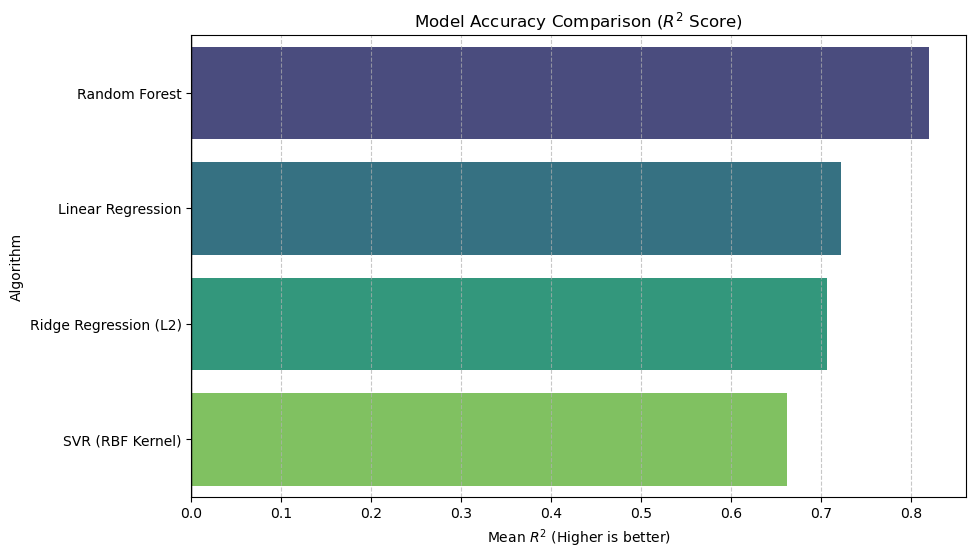

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Mean R2', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison ($R^2$ Score)')
plt.xlabel('Mean $R^2$ (Higher is better)')
plt.ylabel('Algorithm')
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Save the 2 best models in Fuel Efficiency Prediction\models
import joblib
best_models = results_df.sort_values(by="Mean R2", ascending=False).head(2)['Model'].tolist()

# Train the best models on full training data
trained_models = {}

for model_name in best_models:
    model = models[model_name]
    model.fit(X_train_scaled, y_train)
    trained_models[model_name] = model

# Save trained models
joblib.dump(trained_models[best_models[0]], f"../models/{best_models[0].replace(' ', '_')}.joblib")
joblib.dump(trained_models[best_models[1]], f"../models/{best_models[1].replace(' ', '_')}.joblib")
joblib.dump(scaler, "../models/feature_scaler.joblib")

print("Model and Scaler saved successfully in /models")

Model and Scaler saved successfully in /models
